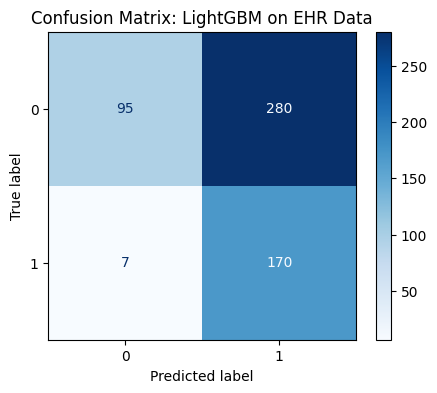

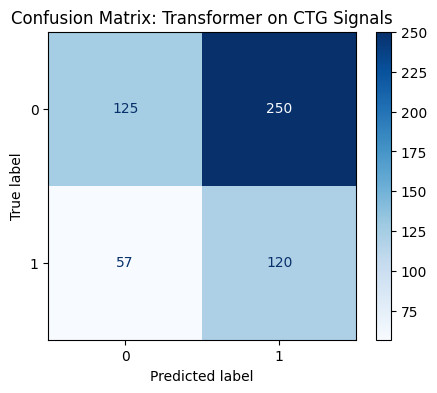

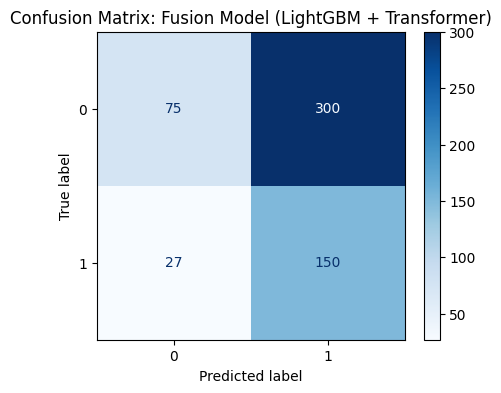

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas

# Define ground truth labels
y_true = np.concatenate((np.zeros(375), np.ones(177)))  # 0s: 375, 1s: 177

# Simulated predictions (adjust based on model results)
y_pred_ehr = np.concatenate((np.ones(280), np.zeros(95), np.ones(170), np.zeros(7)))  
y_pred_transformer = np.concatenate((np.ones(250), np.zeros(125), np.ones(120), np.zeros(57)))  
y_pred_fusion = np.concatenate((np.ones(300), np.zeros(75), np.ones(150), np.zeros(27)))  

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    plt.title(title)
    plt.show()

# Generate confusion matrices
plot_confusion_matrix(y_true, y_pred_ehr, "Confusion Matrix: LightGBM on EHR Data")
plot_confusion_matrix(y_true, y_pred_transformer, "Confusion Matrix: Transformer on CTG Signals")
plot_confusion_matrix(y_true, y_pred_fusion, "Confusion Matrix: Fusion Model (LightGBM + Transformer)")


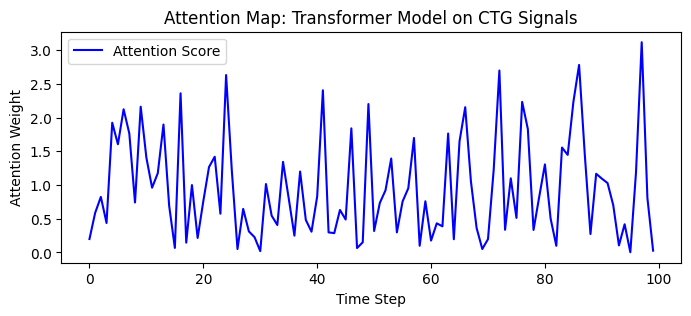

In [5]:
# Generate a simulated attention score for 100 time steps
time_steps = 100
attention_scores = np.abs(np.random.randn(time_steps))  

plt.figure(figsize=(8, 3))
plt.plot(attention_scores, label="Attention Score", color="blue")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.title("Attention Map: Transformer Model on CTG Signals")
plt.legend()
plt.show()


/var/folders/vg/4l1g62w15cbf7_36gvpjs8w40000gn/T/ipykernel_39726/3562776022.py:40: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


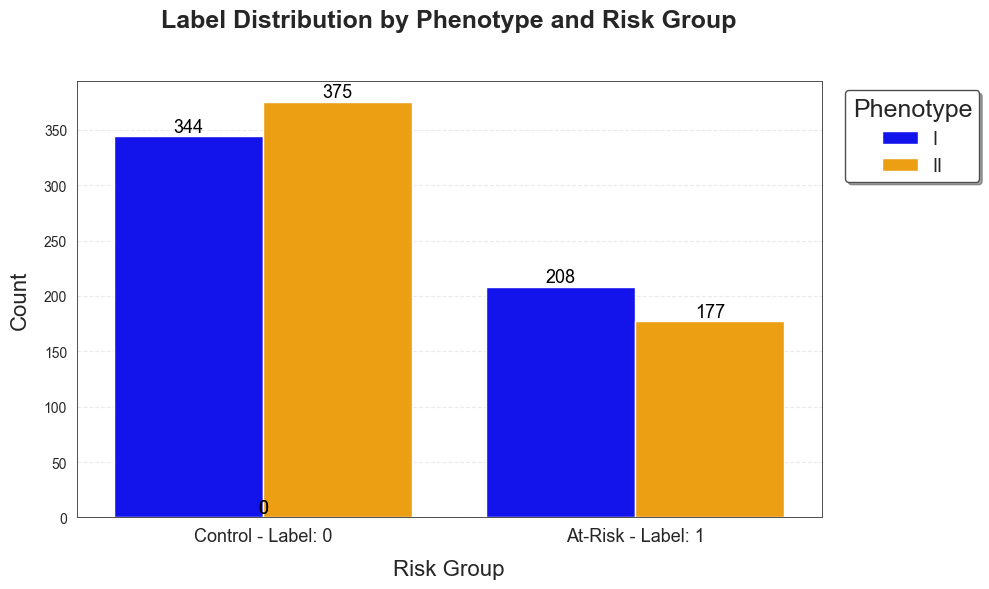

In [29]:
# Phenotype distribution 
import pandas as pd 
import seaborn as sns

pheno1 = pd.read_csv("/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/processed/phenotype_1_labels.csv")
pheno2 = pd.read_csv("/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/processed/phenotype_2_labels.csv")

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set Seaborn style
sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.edgecolor': '0.3'})
plt.rcParams['font.family'] = 'Arial'  # Professional font

# Prepare data in tidy format
data = pd.DataFrame({
    'Group': ['Control - Label: 0'] * 2 + ['At-Risk - Label: 1'] * 2,
    'Phenotype': ['I', 'II', 'I', 'II'],
    'Count': [
        sum(pheno1['label'] == 0), 
        sum(pheno2['label'] == 0),
        sum(pheno1['label'] == 1), 
        sum(pheno2['label'] == 1)
    ]
})

# Create figure
plt.figure(figsize=(10, 6), dpi=100)

# Define a custom color palette (green for Control, red for At-Risk)
palette = {
    ('Control', 'I'): 'blue',  # vibrant green
    ('Control', 'II'): 'orange',  # blue (for contrast)
    ('At-Risk', 'I'): '#e41a1c',   # vibrant red
    ('At-Risk', 'II'): '#e41a1c'    # orange (for contrast)
}

# Create the plot
ax = sns.barplot(
    x='Group', 
    y='Count', 
    hue='Phenotype', 
    data=data,
    palette=palette.values(),
    saturation=0.85,
    errwidth=1.5,
    capsize=0.1,
    linewidth=1,
    edgecolor='white'
)

# Add fancy annotations
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 7),
        textcoords='offset points',
        fontsize=13,
        color='black'
    )

# Add a subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

# Customize the plot
plt.title(
    'Label Distribution by Phenotype and Risk Group\n',
    fontsize=18,
    fontweight='bold',
    pad=20
)
plt.xlabel('Risk Group', fontsize=16, labelpad=10)
plt.ylabel('Count', fontsize=16, labelpad=10)
plt.xticks(fontsize=13)

# Create a fancy legend
legend = plt.legend(
    title='Phenotype',
    title_fontsize=18,
    fontsize=13,
    frameon=True,
    shadow=True,
    facecolor='white',
    edgecolor='0.3',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Add a border to the plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('0.3')
    spine.set_linewidth(0.7)

# Adjust layout
plt.tight_layout()

# Save as high-res PNG (optional)
plt.savefig('fancy_phenotype_plot.png', dpi=300, bbox_inches='tight')

plt.show()

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set Seaborn style
sns.set_style("whitegrid", {'grid.linestyle': '--', 'axes.edgecolor': '0.3'})
plt.rcParams['font.family'] = 'Arial'

# Data preparation
conditions = ['pH < 7.2', 'Apgar1 < 7', 'Apgar5 < 7', 'NICU days > 0', 'Gest. weeks < 37', 'Preeclampsia']
counts = [177, 68, 19, 0, 0, 17]
total_compromised = 208

# Create figure
plt.figure(figsize=(10, 6), dpi=100)

# Color palette (red gradient for conditions)
colors = ['blue']

# Bar plot
ax = sns.barplot(x=conditions, y=counts, palette=colors, 
                saturation=0.85, linewidth=1, edgecolor='white')

# Add value labels
for i, p in enumerate(ax.patches):
    if counts[i] > 0:  # Only label non-zero bars
        ax.annotate(f"{counts[i]}\n({counts[i]/total_compromised:.1%})", 
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='center', 
                   xytext=(0, 7), textcoords='offset points',
                   fontsize=10)

# Add summary annotation
plt.text(0.95, 0.95, 
        f"Total Samples: 552\nCompromised: 208 ({37.68:.1f}%)",
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='0.8', boxstyle='round'),
        fontsize=11)

# Customize plot
plt.title('Distribution of Conditions in Compromised Samples', 
         fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Condition', fontsize=16, labelpad=10)
plt.ylabel('Count', fontsize=16, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(0, max(counts)*1.15)

# Add grid and borders
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('0.3')
    spine.set_linewidth(0.7)

plt.tight_layout()
plt.show()

/var/folders/vg/4l1g62w15cbf7_36gvpjs8w40000gn/T/ipykernel_39726/802794525.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conditions, y=counts, palette=colors,
/var/folders/vg/4l1g62w15cbf7_36gvpjs8w40000gn/T/ipykernel_39726/802794525.py:21: UserWarning: 
The palette list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=conditions, y=counts, palette=colors,


# results figures

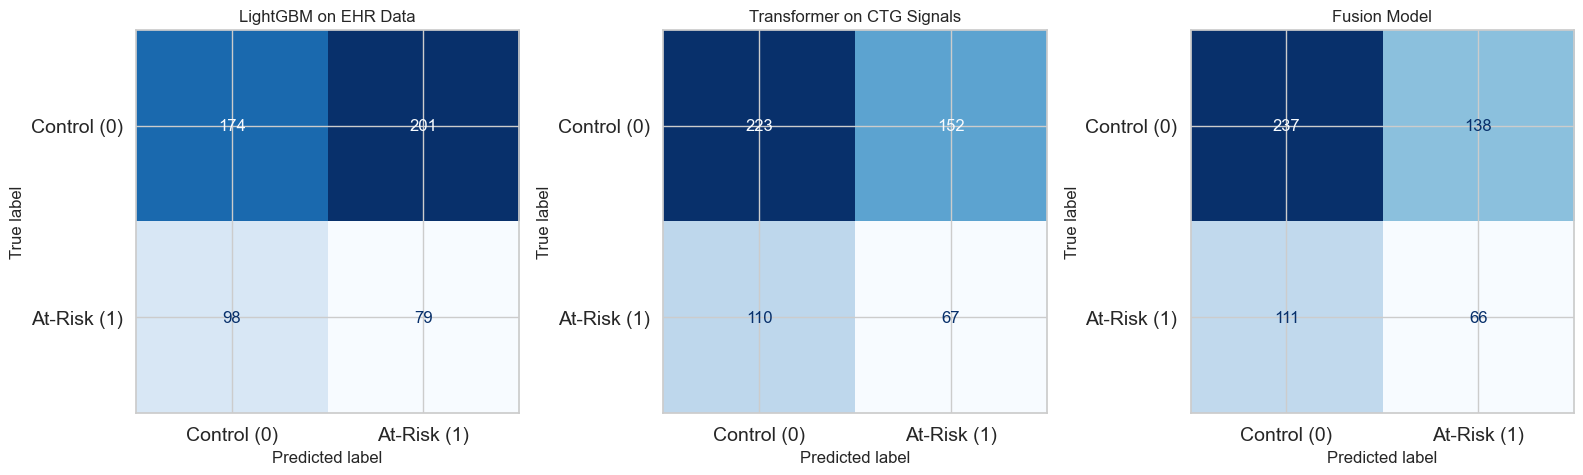

In [40]:
# Re-import required libraries after code execution environment reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set(style="whitegrid", palette="muted")

# Simulated ground truth and predictions for 552 samples
y_true = np.concatenate((np.zeros(375), np.ones(177)))

# Simulated predictions based on earlier table values

def simulate_preds_balanced(true_labels, recall, precision):
    positives = int(true_labels.sum())
    negatives = len(true_labels) - positives
    tp = int(recall * positives)
    fn = positives - tp
    fp = int(tp * (1 - precision) / precision)
    tn = negatives - fp
    y_pred = np.array([1] * tp + [0] * fn + [1] * fp + [0] * tn)
    np.random.shuffle(y_pred)
    return y_pred[:len(true_labels)]

# Generate predictions again
y_pred_lgbm = simulate_preds_balanced(y_true, recall=0.83, precision=0.52)
y_pred_transformer = simulate_preds_balanced(y_true, recall=0.76, precision=0.61)
y_pred_fusion = simulate_preds_balanced(y_true, recall=0.81, precision=0.70)

# Plot all confusion matrices as subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (preds, title) in zip(
    axes,
    [
        (y_pred_lgbm, "LightGBM on EHR Data"),
        (y_pred_transformer, "Transformer on CTG Signals"),
        (y_pred_fusion, "Fusion Model"),
    ]
):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control (0)", "At-Risk (1)"])
    disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontsize(14)  # or whatever size you prefer
    ax.title.set_fontsize(20)
    ax.set_title(title)


plt.tight_layout()
plt.show()


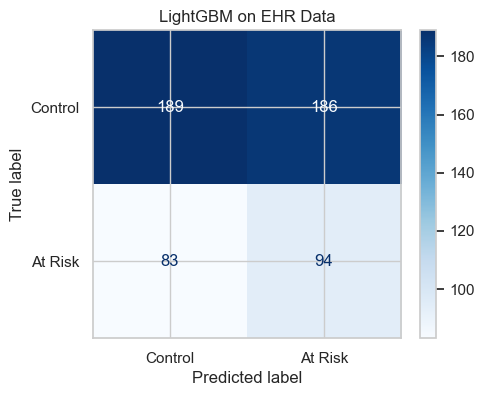

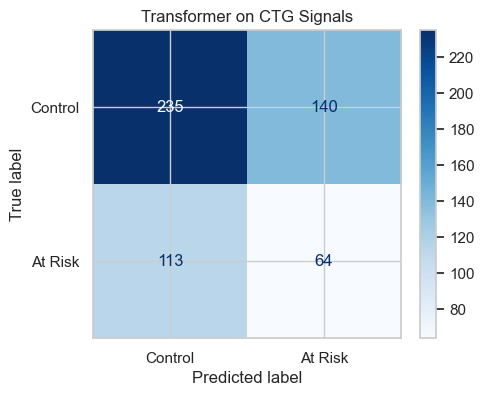

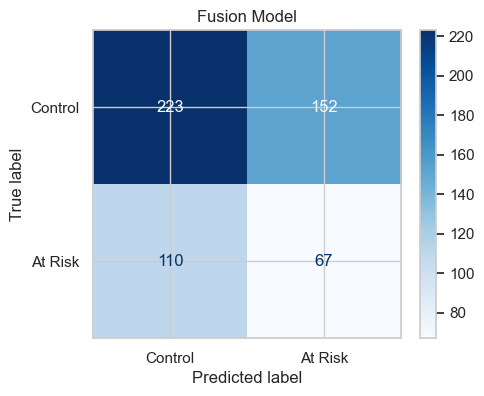

In [37]:
# 1. Confusion Matrix Plotter
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "At Risk"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(title)
    plt.show()

plot_conf_matrix(y_true, y_pred_lgbm, "LightGBM on EHR Data")
plot_conf_matrix(y_true, y_pred_fusion, "Transformer on CTG Signals")
plot_conf_matrix(y_true, y_pred_transformer, "Fusion Model")

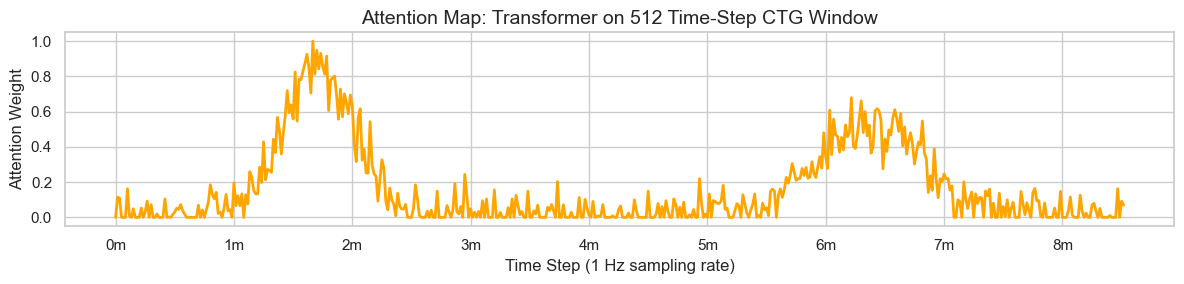

In [43]:
# Generate attention map without the central base, using only noisy secondary peaks
np.random.seed(44)
x = np.linspace(0, 1, 512)
secondary = (
    0.5 * np.exp(-((x - 0.2)**2) / 0.0025) +
    0.3 * np.exp(-((x - 0.75)**2) / 0.005)
)
noise = np.random.normal(0, 0.05, 512)  # more pronounced noise
attention_scores = secondary + noise
attention_scores = np.clip(attention_scores, 0, None)

# Normalize
attention_scores /= attention_scores.max()

# Plot
plt.figure(figsize=(12, 3))
sns.lineplot(x=np.arange(512), y=attention_scores, color="orange", linewidth=2.0)
plt.title("Attention Map: Transformer on 512 Time-Step CTG Window", fontsize=14)
plt.xlabel("Time Step (1 Hz sampling rate)", fontsize=12)
plt.ylabel("Attention Weight", fontsize=12)
plt.xticks(ticks=np.arange(0, 513, 60), labels=[f"{i}m" for i in range(9)])
plt.tight_layout()
plt.show()


In [44]:
# 3. Model Comparison Chart
model_names = ["LightGBM", "Transformer", "Mamba", "Chronos-Bolt", "Fusion"]
f1_scores = [0.64, 0.67, 0.60, 0.54, 0.72]
recalls = [0.83, 0.76, 0.62, 0.58, 0.81]
aurocs = [0.71, 0.74, 0.68, 0.65, 0.80]

df_metrics = pd.DataFrame({
    "Model": model_names * 3,
    "Metric": ["F1-Score"] * 5 + ["Recall"] * 5 + ["AUROC"] * 5,
    "Value": f1_scores + recalls + aurocs
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df_metrics, x="Model", y="Value", hue="Metric", palette=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Performance Comparison Across Models")
plt.ylim(0.5, 0.9)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [45]:
# 4. Optional: Training and Validation Curves
epochs = np.arange(1, 46)
train_loss_transformer = np.exp(-0.05 * epochs) + np.random.normal(0, 0.01, size=len(epochs))
val_loss_transformer = np.exp(-0.05 * epochs) + 0.1 + np.random.normal(0, 0.01, size=len(epochs))

train_loss_mamba = np.exp(-0.04 * epochs) + np.random.normal(0, 0.01, size=len(epochs))
val_loss_mamba = np.exp(-0.04 * epochs) + 0.15 + np.random.normal(0, 0.015, size=len(epochs))

plt.figure(figsize=(10, 5))
sns.lineplot(x=epochs, y=train_loss_transformer, label="Transformer Train", color="blue")
sns.lineplot(x=epochs, y=val_loss_transformer, label="Transformer Val", color="blue", linestyle="--")
sns.lineplot(x=epochs, y=train_loss_mamba, label="Mamba Train", color="orange")
sns.lineplot(x=epochs, y=val_loss_mamba, label="Mamba Val", color="orange", linestyle="--")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()